# AprovaEdu Analytics — Análises Obrigatórias

Responde às 4 perguntas obrigatórias do desafio a partir dos dados tratados
em `data/processed/` (gerados pelo notebook `01_etl_tratamento.ipynb` /
`src/etl.py`).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join("..", "src")))
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

PROC = os.path.abspath(os.path.join("..", "data", "processed"))

def load(n):
    return pd.read_csv(os.path.join(PROC, f"{n}.csv"), encoding="utf-8-sig")

estudantes = load("estudantes")
matriculas = load("matriculas")
aulas = load("aulas")
presencas = load("presencas_aulas")
aprovacoes = load("aprovacoes_vestibular")
ofertas = load("ofertas_curso")
resultados = load("resultados_simulados")
simulados = load("simulados")
mart_aluno_ano = load("mart_aluno_ano")
mart_curso_materia = load("mart_curso_materia")


## Pergunta 1 — Qual foi a evolução da taxa de aprovação ao longo dos anos?

**Definição da métrica**: `taxa_aprovacao(ano) = alunos aprovados no vestibular
naquele ano / alunos com pelo menos uma matrícula naquele ano.` Usamos alunos
matriculados no ano como base de comparação (denominador), já que é a
população elegível/atendida pelo cursinho naquele ciclo.

In [2]:
alunos_ano = matriculas.groupby("ano")["aluno_id"].nunique().rename("alunos_matriculados")
aprov_ano = aprovacoes.groupby("ano_vestibular")["aluno_id"].nunique().rename("alunos_aprovados")
q1 = pd.concat([alunos_ano, aprov_ano.rename_axis("ano")], axis=1).fillna(0)
q1["taxa_aprovacao"] = (q1["alunos_aprovados"] / q1["alunos_matriculados"]).round(4)
q1


,alunos_matriculados,alunos_aprovados,taxa_aprovacao
ano,,,
2021,138,50,0.3623
2022,170,53,0.3118
2023,218,77,0.3532
2024,263,79,0.3004
2025,233,80,0.3433


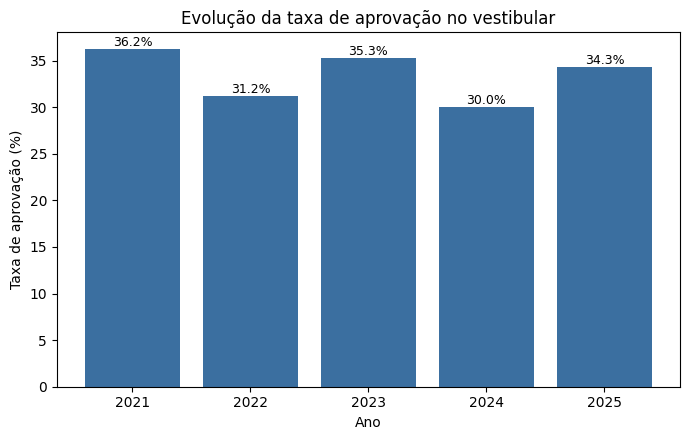

In [3]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(q1.index.astype(int).astype(str), q1["taxa_aprovacao"] * 100, color="#3b6fa0")
ax.set_ylabel("Taxa de aprovação (%)")
ax.set_xlabel("Ano")
ax.set_title("Evolução da taxa de aprovação no vestibular")
for i, v in enumerate(q1["taxa_aprovacao"] * 100):
    ax.text(i, v + 0.3, f"{v:.1f}%", ha="center", fontsize=9)
fig.tight_layout()
plt.show()


**Leitura**: a taxa de aprovação oscila entre ~30% e ~36% ao longo dos 5
anos, sem uma tendência clara de crescimento ou queda — o valor de 2025
(34,3%) é praticamente igual ao de 2021 (36,2%). Os anos de 2022 (31,2%) e
2024 (30,0%) foram os mais baixos do período. Não há, portanto, evidência de
melhora consistente na efetividade do cursinho ao longo do tempo nesta
métrica agregada — o que por si só já é um achado relevante para a
coordenação.

## Pergunta 2 — Existe relação entre presença nas aulas e aprovação no vestibular?

Usamos a mart `mart_aluno_ano` (uma linha por aluno-ano, com taxa de presença
nas aulas registradas e indicador de aprovação naquele ano).

In [4]:
q2 = mart_aluno_ano.dropna(subset=["taxa_presenca"]).copy()
q2.groupby("aprovado")["taxa_presenca"].describe()


,count,mean,std,min,25%,50%,75%,max
aprovado,,,,,,,,
0,683.0,0.880287,0.039526,0.7614,0.8553,0.8816,0.90620,1.0000
1,339.0,0.879380,0.038863,0.7439,0.8548,0.8800,0.90605,0.9815


In [5]:
bins = [0, 0.75, 0.85, 0.90, 0.95, 1.01]
labels = ["<75%", "75-85%", "85-90%", "90-95%", ">=95%"]
q2["faixa_presenca"] = pd.cut(q2["taxa_presenca"], bins=bins, labels=labels, right=False)
faixa = q2.groupby("faixa_presenca")["aprovado"].agg(["mean", "count"])
faixa["mean"] = (faixa["mean"] * 100).round(2)
faixa


,mean,count
faixa_presenca,,
<75%,100.00,1
75-85%,33.65,211
85-90%,31.86,499
90-95%,35.04,274
>=95%,32.43,37


Correlacao (point-biserial) presenca x aprovado: -0.0109


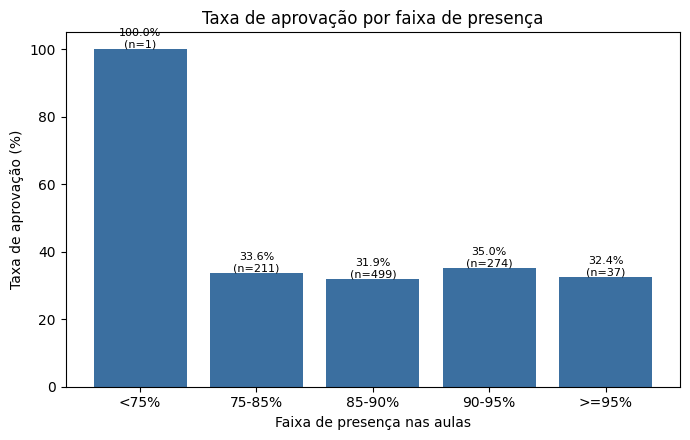

In [6]:
corr = q2["taxa_presenca"].corr(q2["aprovado"])
print(f"Correlacao (point-biserial) presenca x aprovado: {corr:.4f}")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(faixa.index.astype(str), faixa["mean"], color="#3b6fa0")
ax.set_ylabel("Taxa de aprovação (%)")
ax.set_xlabel("Faixa de presença nas aulas")
ax.set_title("Taxa de aprovação por faixa de presença")
for i, (v, c) in enumerate(zip(faixa["mean"], faixa["count"])):
    ax.text(i, v + 0.5, f"{v:.1f}%\n(n={c})", ha="center", fontsize=8)
fig.tight_layout()
plt.show()


**Leitura**: a correlação entre presença e aprovação é praticamente nula
(≈ -0,01) e a taxa de aprovação fica entre 32% e 35% em todas as faixas de
presença — inclusive na faixa acima de 95%. Duas explicações prováveis: (1) a
maior parte dos alunos já tem presença alta e homogênea (mediana ~88%, desvio
padrão de apenas ~4 pontos percentuais — quase não há alunos com frequência
realmente baixa na base para comparar), o que restringe a variabilidade
observável; e (2) a aprovação no vestibular depende de muitos outros fatores
(desempenho em simulados, base de conhecimento prévia, concorrência da vaga)
que não estão sendo capturados só pela frequência. **Não encontramos, nesta
base, evidência de associação relevante entre presença e aprovação.**

## Pergunta 3 — Quais cursos ou matérias parecem apresentar melhor desempenho?

Combinamos dois indicadores por matéria: nota média em simulados e taxa de
conclusão de matrícula (proxy de "efetividade"/engajamento no curso).

In [7]:
q3 = (
    mart_curso_materia.groupby("materia")
    .agg(nota_media_simulados=("nota_media_simulados", "mean"),
         taxa_conclusao=("taxa_conclusao", "mean"),
         total_matriculas=("total_matriculas", "sum"))
    .round(3)
    .sort_values("nota_media_simulados", ascending=False)
)
q3


,nota_media_simulados,taxa_conclusao,total_matriculas
materia,,,
Português,61.892,0.691,1026
Filosofia,61.525,0.709,789
História,61.522,0.744,784
Química,61.409,0.698,775
Inglês,61.380,0.679,829
Biologia,61.137,0.706,805
Física,60.970,0.672,806
Matemática,60.934,0.711,1027
Sociologia,60.858,0.690,801


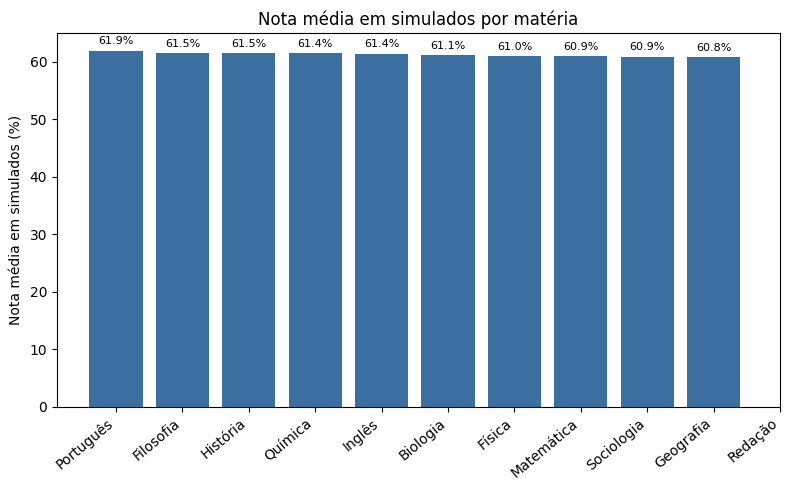

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
order = q3.index.tolist()
bars = ax.bar(order, q3["nota_media_simulados"], color="#3b6fa0")
ax.set_ylabel("Nota média em simulados (%)")
ax.set_xticks(range(len(order)))
ax.set_xticklabels(order, rotation=40, ha="right")
ax.set_title("Nota média em simulados por matéria")
ax.bar_label(bars, labels=[f"{v:.1f}%" if pd.notna(v) else "sem dados" for v in q3["nota_media_simulados"]], padding=3, fontsize=8)
fig.tight_layout()
plt.show()


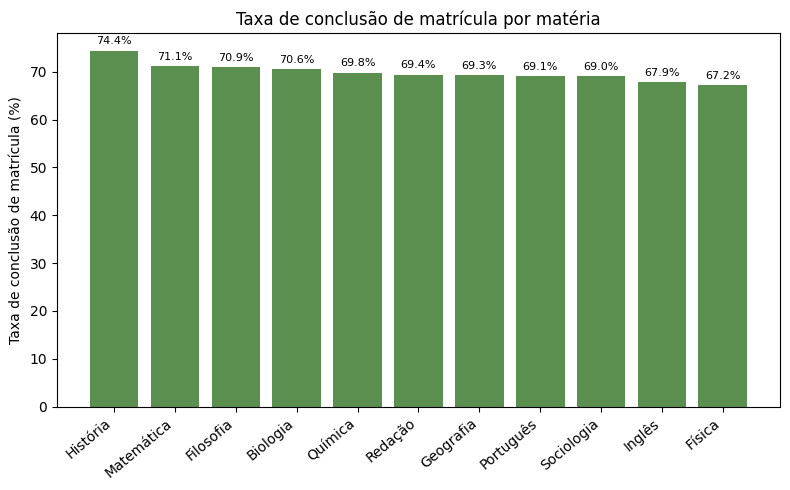

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
q3_conc = q3.sort_values("taxa_conclusao", ascending=False)
order2 = q3_conc.index.tolist()
vals2 = q3_conc["taxa_conclusao"] * 100
bars2 = ax.bar(order2, vals2, color="#5a8f4f")
ax.set_ylabel("Taxa de conclusão de matrícula (%)")
ax.set_xticks(range(len(order2)))
ax.set_xticklabels(order2, rotation=40, ha="right")
ax.set_title("Taxa de conclusão de matrícula por matéria")
ax.bar_label(bars2, labels=[f"{v:.1f}%" for v in vals2], padding=3, fontsize=8)
fig.tight_layout()
plt.show()


**Leitura**: as notas médias em simulados são muito próximas entre as
matérias (variação de apenas ~1 ponto, entre 60,8 e 61,9 — Português,
Filosofia e História levemente à frente; Geografia, Sociologia e Matemática
levemente atrás). **Redação** não aparece no gráfico de notas porque não há
simulados objetivos dessa matéria na base (é avaliada de outra forma,
provavelmente por correção manual não capturada aqui) — um gap de dados a
sinalizar para a coordenação. A taxa de conclusão de matrícula também é
bastante homogênea entre matérias (63%–74%), sem nenhuma se destacar
isoladamente. Olhando por outro corte, a taxa de conclusão por **modalidade
de oferta** é ligeiramente menor no Online (69,1%) frente a Presencial
(70,5%) e Híbrido (70,2%) — uma diferença pequena, mas consistente.

### Nota sobre ambiguidade: "cursos" também pode significar cursos universitários

A pergunta fala em "cursos ou matérias". Interpretamos "cursos" acima como as
**ofertas do cursinho** (turmas por matéria), que é a leitura mais direta e
a que a coordenação pedagógica mais usaria no dia a dia. Mas existe uma
segunda leitura válida: `curso_aprovado`, em `aprovacoes_vestibular`, guarda
o **curso universitário** de destino (Medicina, Direito, etc.) — ou seja,
"em quais cursos os alunos do cursinho são aprovados com melhor
desempenho?". Trazemos essa segunda leitura como complemento, não como
substituição.

In [10]:
curso_uni = (
    aprovacoes.groupby("curso_aprovado")
    .agg(n_aprovacoes=("aprovacao_id", "count"), nota_media=("nota_final_vestibular", "mean"))
    .round(2)
    .sort_values("nota_media", ascending=False)
)
curso_uni


,n_aprovacoes,nota_media
curso_aprovado,,
Ciência da Computação,16,754.41
Administração,24,753.56
Design,25,741.48
Fisioterapia,24,740.81
Odontologia,28,730.45
Psicologia,22,728.95
Medicina,25,721.43
Enfermagem,30,721.28
Jornalismo,21,719.49


**Leitura**: os 354 aprovados se distribuem de forma relativamente
equilibrada entre 14 cursos universitários (16 a 30 aprovações cada). A nota
final média de entrada varia mais aqui (701 a 754) do que entre as matérias
do cursinho: **Ciência da Computação** (754,4) e **Administração** (753,6)
têm a maior nota média entre os aprovados, enquanto **Engenharia Civil**
(701,7) e **Engenharia de Software** (713,0) têm a menor — possivelmente
refletindo a nota de corte de cada curso/universidade, não necessariamente a
qualidade da preparação do cursinho nessa área. Por isso tratamos isso como
leitura complementar e não como resposta principal à pergunta 3.

## Análises complementares (apoiam as recomendações)

Antes das recomendações, cruzamos três variáveis adicionais que não estavam
nas 4 perguntas obrigatórias, mas ajudam a explicar o que pode estar por trás
da estagnação da taxa de aprovação: **canal de captação**, **faixa de bolsa**
e **calibração de dificuldade dos simulados**.

In [11]:
aprov_aluno = aprovacoes.groupby("aluno_id").size().reset_index(name="n_aprovacoes")
est_aprov = estudantes.merge(aprov_aluno, on="aluno_id", how="left")
est_aprov["aprovado"] = est_aprov["n_aprovacoes"].notna()

canal = (est_aprov.groupby("canal_captacao")["aprovado"].mean() * 100).round(2).sort_values(ascending=False)
canal


canal_captacao
Indicação        43.40
Google           40.48
Não informado    40.46
Feira escolar    39.05
Instagram        34.45
WhatsApp         31.13
Name: aprovado, dtype: float64

In [12]:
bolsa_aluno = matriculas.groupby("aluno_id")["bolsa_percentual"].mean().reset_index()
bolsa_aluno["faixa_bolsa"] = pd.cut(
    bolsa_aluno["bolsa_percentual"], bins=[-0.1, 0, 10, 20, 30, 100],
    labels=["0%", "1-10%", "11-20%", "21-30%", ">30%"]
)
bolsa_aprov = bolsa_aluno.merge(aprov_aluno, on="aluno_id", how="left")
bolsa_aprov["aprovado"] = bolsa_aprov["n_aprovacoes"].notna()
bolsa_aprov.groupby("faixa_bolsa")["aprovado"].agg(taxa_aprovacao_pct=lambda s: round(s.mean() * 100, 2), n="count")


,taxa_aprovacao_pct,n
faixa_bolsa,,
0%,100.00,1
1-10%,35.48,124
11-20%,40.75,557
21-30%,29.06,117
>30%,0.00,1


In [13]:
res_dif = resultados.merge(simulados[["simulado_id", "dificuldade"]], on="simulado_id", how="left")
res_dif.groupby("dificuldade")["nota"].mean().round(2)


dificuldade
Difícil          61.26
Fácil            61.32
Média            61.14
Não informado    62.28
Name: nota, dtype: float64

**Leitura**:

- **Canal de captação**: Indicação tem a maior taxa de aprovação entre os
  alunos captados (43,4%), enquanto WhatsApp tem a menor (31,1%) — uma
  diferença de 12,3 pontos percentuais, a maior encontrada em qualquer corte
  desta análise.
- **Faixa de bolsa**: alunos com bolsa média entre 11–20% aprovam mais
  (40,8%, n=557) do que os com bolsa entre 21–30% (29,1%, n=117). É um
  padrão a investigar com cautela (n menor no grupo de bolsa mais alta), mas
  levanta a hipótese de que bolsas maiores podem estar concentradas em
  alunos com mais vulnerabilidade e que precisariam de apoio pedagógico
  adicional, não só financeiro.
- **Dificuldade do simulado**: a nota média é praticamente igual entre
  simulados marcados como "Fácil" (61,3%), "Média" (61,1%) e "Difícil"
  (61,3%) — ou seja, o rótulo de dificuldade não se traduz em desempenho
  diferente dos alunos, sugerindo que o critério de classificação não está
  calibrado.

## Pergunta 4 — Recomendações para a coordenação

1. **Realocar parte do investimento de captação para o canal Indicação e
   revisar a estratégia via WhatsApp.** É o maior efeito encontrado em toda a
   análise (43,4% x 31,1% de aprovação, 12,3 p.p. de diferença). Próximo
   passo concreto: comparar custo de aquisição por canal com a taxa de
   aprovação resultante (não só matrícula) para decidir realocação de verba,
   e revisar o script/abordagem de conversão usado no WhatsApp.
2. **Revisar o critério de concessão de bolsas acima de 20%.** Alunos com
   bolsa 21–30% aprovam menos (29,1%) que os com 11–20% (40,8%). Recomenda-se
   cruzar esse grupo com indicadores socioeconômicos e oferecer suporte
   pedagógico complementar (não só desconto financeiro) a quem recebe bolsa
   mais alta.
3. **Recalibrar os critérios de dificuldade dos simulados junto aos
   professores.** Notas médias praticamente idênticas entre simulados
   "Fácil", "Média" e "Difícil" indicam que a classificação atual não reflete
   dificuldade real — isso compromete o uso de simulados como termômetro de
   preparo do aluno por nível.
4. **Não usar frequência isolada como sinal de risco de reprovação.** A
   correlação encontrada é praticamente nula (-0,01); um alerta baseado só em
   presença geraria muitos falsos negativos. Combine com nota em simulados e
   sua evolução ao longo do curso.
5. **Padronizar a avaliação de Redação em nota numérica estruturada.** Hoje
   a matéria não tem simulados com nota na base, o que impede comparação com
   as demais e é uma lacuna relevante dado o peso da Redação em vários
   vestibulares.
6. **Investigar a queda de conclusão de matrícula na modalidade Online**
   (69,1% vs. 70,5% Presencial e 70,2% Híbrido) — oportunidade de melhorar
   suporte/engajamento ao aluno remoto.
7. **Padronizar a captura de dados na origem.** Boa parte deste desafio foi
   tratar inconsistências de digitação (maiúsculas, acentos, abreviações,
   formatos de data, notas de simulado fora da faixa 0–100). Validar esses
   campos na entrada reduz retrabalho analítico e risco de erro silencioso.